In [ ]:
# ============================================================
# Cell 1: Import Libraries
# All the tools we need for data handling, modeling, and plots
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("All libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

All libraries imported successfully.
PyTorch version: 2.10.0+cu128
GPU available: True


In [ ]:
# ============================================================
# Cell 2: Download and Load the Dataset
# UCI server was unavailable so we use kagglehub to fetch
# the same dataset directly into the Colab environment
# ============================================================

import kagglehub

path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Dataset downloaded to:", path)

df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

100%|██████████| 6.03M/6.03M [00:00<00:00, 8.31MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1
Shape: (253680, 22)

First 5 rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# ============================================================
# Cell 3: Explore the Data
# Check for missing values, class balance, and basic stats
# ============================================================

# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Class distribution for diabetes target
print("\nClass distribution (Diabetes_binary):")
print(df["Diabetes_binary"].value_counts())
print(df["Diabetes_binary"].value_counts(normalize=True).round(3))

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Class distribution (Diabetes_binary):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    0.861
1.0    0.139
Name: proportion, dtype: float64

Basic statistics:
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001      

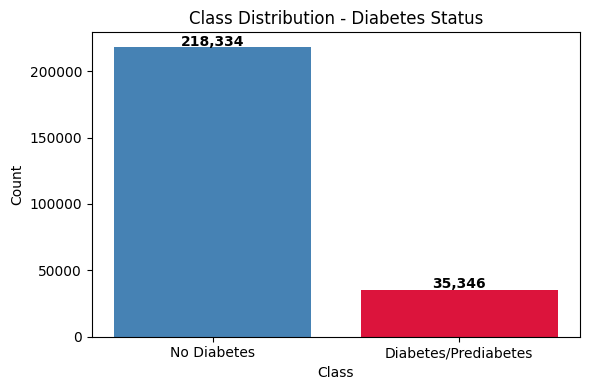

In [ ]:
# ============================================================
# Cell 4: Visualize Class Imbalance
# Plot how many diabetic vs non-diabetic cases exist
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

counts = df["Diabetes_binary"].value_counts()
ax.bar(["No Diabetes", "Diabetes/Prediabetes"], counts.values, color=["steelblue", "crimson"])
ax.set_title("Class Distribution - Diabetes Status")
ax.set_ylabel("Count")
ax.set_xlabel("Class")

for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 5: Prepare Data for Classification (RQ1)
# Target: Diabetes_binary | Features: all other 21 columns
# ============================================================

X_clf = df.drop(columns=["Diabetes_binary"])
y_clf = df["Diabetes_binary"]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf        # keeps class ratio the same in train and test
)

scaler_clf = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s  = scaler_clf.transform(X_clf_test)

print("Classification data ready.")
print("Train size:", X_clf_train_s.shape)
print("Test size: ", X_clf_test_s.shape)

Classification data ready.
Train size: (202944, 21)
Test size:  (50736, 21)


In [ ]:
# ============================================================
# Cell 6: Prepare Data for Regression (RQ2)
# Target: BMI | Features: all other columns except Diabetes_binary
# ============================================================

X_reg = df.drop(columns=["BMI", "Diabetes_binary"])
y_reg = df["BMI"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s  = scaler_reg.transform(X_reg_test)

print("Regression data ready.")
print("Train size:", X_reg_train_s.shape)
print("Test size: ", X_reg_test_s.shape)

Regression data ready.
Train size: (202944, 20)
Test size:  (50736, 20)


In [ ]:
# ============================================================
# Cell 7: Baseline Classification - Logistic Regression
# Simple, interpretable baseline model to beat
# ============================================================

lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_clf_train_s, y_clf_train)

y_pred_lr = lr_clf.predict(X_clf_test_s)

print("=== Logistic Regression - Classification Report ===")
print(classification_report(y_clf_test, y_pred_lr,
                             target_names=["No Diabetes", "Diabetes"]))

=== Logistic Regression - Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.88      0.98      0.92     43667
    Diabetes       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



In [ ]:
# ============================================================
# Cell 8: Simple Neural Network - Classification
# One hidden layer with ReLU activation
# ============================================================

class SimpleClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_classifier(model, X_train, y_train, epochs=20, learning_rate=0.001):
    """Train a binary classification neural network and return loss history."""

    dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train.values)
    )
    loader    = DataLoader(dataset, batch_size=512, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    loss_fn   = nn.BCELoss()
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")
        scheduler.step()

    return model, loss_history


input_dim = X_clf_train_s.shape[1]
simple_clf_nn = SimpleClassifierNN(input_dim)
simple_clf_nn, simple_clf_losses = train_classifier(simple_clf_nn, X_clf_train_s, y_clf_train)

simple_clf_nn.eval()
with torch.no_grad():
    raw_preds = simple_clf_nn(torch.FloatTensor(X_clf_test_s))
    y_pred_simple_nn = (raw_preds > 0.5).int().numpy()

print("\n=== Simple Neural Network - Classification Report ===")
print(classification_report(y_clf_test, y_pred_simple_nn,
                             target_names=["No Diabetes", "Diabetes"]))

Epoch 01/50 - Loss: 0.3523
Epoch 02/50 - Loss: 0.3133
Epoch 03/50 - Loss: 0.3119
Epoch 04/50 - Loss: 0.3113
Epoch 05/50 - Loss: 0.3112
Epoch 06/50 - Loss: 0.3107
Epoch 07/50 - Loss: 0.3105
Epoch 08/50 - Loss: 0.3106
Epoch 09/50 - Loss: 0.3103
Epoch 10/50 - Loss: 0.3101
Epoch 11/50 - Loss: 0.3097
Epoch 12/50 - Loss: 0.3096
Epoch 13/50 - Loss: 0.3097
Epoch 14/50 - Loss: 0.3097
Epoch 15/50 - Loss: 0.3095
Epoch 16/50 - Loss: 0.3094
Epoch 17/50 - Loss: 0.3094
Epoch 18/50 - Loss: 0.3094
Epoch 19/50 - Loss: 0.3093
Epoch 20/50 - Loss: 0.3092
Epoch 21/50 - Loss: 0.3089
Epoch 22/50 - Loss: 0.3090
Epoch 23/50 - Loss: 0.3091
Epoch 24/50 - Loss: 0.3089
Epoch 25/50 - Loss: 0.3090
Epoch 26/50 - Loss: 0.3090
Epoch 27/50 - Loss: 0.3089
Epoch 28/50 - Loss: 0.3089
Epoch 29/50 - Loss: 0.3089
Epoch 30/50 - Loss: 0.3090
Epoch 31/50 - Loss: 0.3087
Epoch 32/50 - Loss: 0.3087
Epoch 33/50 - Loss: 0.3087
Epoch 34/50 - Loss: 0.3087
Epoch 35/50 - Loss: 0.3086
Epoch 36/50 - Loss: 0.3087
Epoch 37/50 - Loss: 0.3087
E

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
# ============================================================
# Cell 8 (revised): Simple Neural Network - Classification
# Added class weighting to handle the 86/14 class imbalance
# ============================================================

class SimpleClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_classifier(model, X_train, y_train, epochs=20, learning_rate=0.001):

    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])

    dataset   = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train.values)
    )
    loader    = DataLoader(dataset, batch_size=512, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")
        scheduler.step()

    return model, loss_history


# Rebuild model without Sigmoid since BCEWithLogitsLoss handles it internally
class SimpleClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()


input_dim = X_clf_train_s.shape[1]
simple_clf_nn = SimpleClassifierNN(input_dim)
simple_clf_nn, simple_clf_losses = train_classifier(simple_clf_nn, X_clf_train_s, y_clf_train, epochs=50)

simple_clf_nn.eval()
with torch.no_grad():
    raw_preds = simple_clf_nn(torch.FloatTensor(X_clf_test_s))

thresholds = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
for t in thresholds:
    y_pred = (raw_preds > t).int().numpy()
    report = classification_report(
        y_clf_test, y_pred,
        target_names=["No Diabetes", "Diabetes"],
        output_dict=True
    )
    print(f"Threshold {t:+.1f} | "
          f"Recall: {report['Diabetes']['recall']:.3f} | "
          f"Precision: {report['Diabetes']['precision']:.3f} | "
          f"F1: {report['Diabetes']['f1-score']:.3f}")

y_pred_simple_nn = (raw_preds > 0.5).int().numpy()

print("\n=== Simple Neural Network - Classification Report ===")
print(classification_report(y_clf_test, y_pred_simple_nn,
                             target_names=["No Diabetes", "Diabetes"]))



Epoch 01/50 - Loss: 0.9054
Epoch 02/50 - Loss: 0.8672
Epoch 03/50 - Loss: 0.8632
Epoch 04/50 - Loss: 0.8616
Epoch 05/50 - Loss: 0.8608
Epoch 06/50 - Loss: 0.8591
Epoch 07/50 - Loss: 0.8584
Epoch 08/50 - Loss: 0.8584
Epoch 09/50 - Loss: 0.8581
Epoch 10/50 - Loss: 0.8576
Epoch 11/50 - Loss: 0.8570
Epoch 12/50 - Loss: 0.8567
Epoch 13/50 - Loss: 0.8567
Epoch 14/50 - Loss: 0.8565
Epoch 15/50 - Loss: 0.8563
Epoch 16/50 - Loss: 0.8561
Epoch 17/50 - Loss: 0.8563
Epoch 18/50 - Loss: 0.8558
Epoch 19/50 - Loss: 0.8560
Epoch 20/50 - Loss: 0.8558
Epoch 21/50 - Loss: 0.8555
Epoch 22/50 - Loss: 0.8556
Epoch 23/50 - Loss: 0.8556
Epoch 24/50 - Loss: 0.8558
Epoch 25/50 - Loss: 0.8554
Epoch 26/50 - Loss: 0.8555
Epoch 27/50 - Loss: 0.8553
Epoch 28/50 - Loss: 0.8552
Epoch 29/50 - Loss: 0.8557
Epoch 30/50 - Loss: 0.8551
Epoch 31/50 - Loss: 0.8552
Epoch 32/50 - Loss: 0.8554
Epoch 33/50 - Loss: 0.8556
Epoch 34/50 - Loss: 0.8554
Epoch 35/50 - Loss: 0.8555
Epoch 36/50 - Loss: 0.8551
Epoch 37/50 - Loss: 0.8553
E

In [ ]:
# ============================================================
# Cell 9: Deep Neural Network - Classification
# Multiple hidden layers with Dropout to prevent overfitting
# ============================================================

class DeepClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()


deep_clf_nn = DeepClassifierNN(input_dim)
deep_clf_nn, deep_clf_losses = train_classifier(
    deep_clf_nn, X_clf_train_s, y_clf_train, epochs=30
)

# deep_clf_nn.eval()
# with torch.no_grad():
#     raw_preds      = deep_clf_nn(torch.FloatTensor(X_clf_test_s))
#     y_pred_deep_nn = (raw_preds > 0.0).int().numpy()

# print("\n=== Deep Neural Network - Classification Report ===")
# print(classification_report(y_clf_test, y_pred_deep_nn,
#                              target_names=["No Diabetes", "Diabetes"]))

# deep_clf_nn.eval()
# with torch.no_grad():
#     raw_preds_deep = deep_clf_nn(torch.FloatTensor(X_clf_test_s))

# thresholds = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
# for t in thresholds:
#     y_pred = (raw_preds_deep > t).int().numpy()
#     report = classification_report(
#         y_clf_test, y_pred,
#         target_names=["No Diabetes", "Diabetes"],
#         output_dict=True,
#         zero_division=0
#     )
#     print(f"Threshold {t:+.1f} | "
#           f"Recall: {report['Diabetes']['recall']:.3f} | "
#           f"Precision: {report['Diabetes']['precision']:.3f} | "
#           f"F1: {report['Diabetes']['f1-score']:.3f}")


deep_clf_nn.eval()
with torch.no_grad():
    raw_preds_deep = deep_clf_nn(torch.FloatTensor(X_clf_test_s))

thresholds = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
for t in thresholds:
    y_pred = (raw_preds_deep > t).int().numpy()
    report = classification_report(
        y_clf_test, y_pred,
        target_names=["No Diabetes", "Diabetes"],
        output_dict=True,
        zero_division=0
    )
    print(f"Threshold {t:+.1f} | "
          f"Recall: {report['Diabetes']['recall']:.3f} | "
          f"Precision: {report['Diabetes']['precision']:.3f} | "
          f"F1: {report['Diabetes']['f1-score']:.3f}")

y_pred_deep_nn = (raw_preds_deep > 0.5).int().numpy()

print("\n=== Deep Neural Network - Classification Report ===")
print(classification_report(y_clf_test, y_pred_deep_nn,
                             target_names=["No Diabetes", "Diabetes"]))

Epoch 01/30 - Loss: 0.9131
Epoch 02/30 - Loss: 0.8778
Epoch 03/30 - Loss: 0.8745
Epoch 04/30 - Loss: 0.8707
Epoch 05/30 - Loss: 0.8699
Epoch 06/30 - Loss: 0.8661
Epoch 07/30 - Loss: 0.8661
Epoch 08/30 - Loss: 0.8656
Epoch 09/30 - Loss: 0.8653
Epoch 10/30 - Loss: 0.8646
Epoch 11/30 - Loss: 0.8640
Epoch 12/30 - Loss: 0.8637
Epoch 13/30 - Loss: 0.8634
Epoch 14/30 - Loss: 0.8628
Epoch 15/30 - Loss: 0.8619
Epoch 16/30 - Loss: 0.8623
Epoch 17/30 - Loss: 0.8610
Epoch 18/30 - Loss: 0.8620
Epoch 19/30 - Loss: 0.8617
Epoch 20/30 - Loss: 0.8619
Epoch 21/30 - Loss: 0.8610
Epoch 22/30 - Loss: 0.8602
Epoch 23/30 - Loss: 0.8615
Epoch 24/30 - Loss: 0.8611
Epoch 25/30 - Loss: 0.8605
Epoch 26/30 - Loss: 0.8598
Epoch 27/30 - Loss: 0.8617
Epoch 28/30 - Loss: 0.8610
Epoch 29/30 - Loss: 0.8615
Epoch 30/30 - Loss: 0.8610
Threshold -2.0 | Recall: 0.982 | Precision: 0.186 | F1: 0.313
Threshold -1.5 | Recall: 0.965 | Precision: 0.203 | F1: 0.336
Threshold -1.0 | Recall: 0.937 | Precision: 0.227 | F1: 0.365
Thre

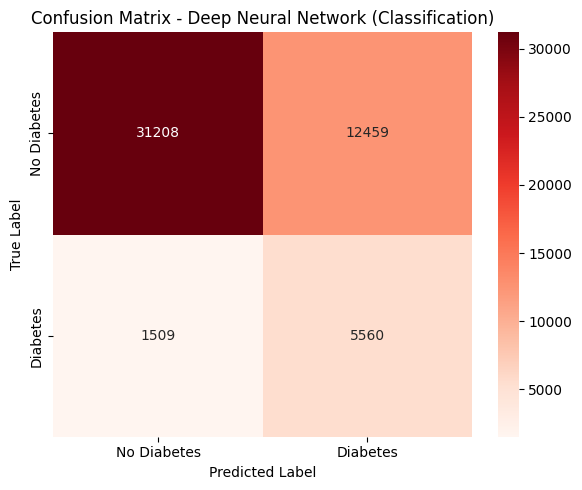

In [ ]:
# ============================================================
# Cell 10: Classification Results - Confusion Matrix
# Visualize how well the best model predicts each class
# ============================================================

cm = confusion_matrix(y_clf_test, y_pred_deep_nn)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"], ax=ax)
ax.set_title("Confusion Matrix - Deep Neural Network (Classification)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 11: Baseline Regression - Linear Regression
# Simplest possible model to establish a performance floor
# ============================================================

lin_reg = LinearRegression()
lin_reg.fit(X_reg_train_s, y_reg_train)
y_pred_linreg = lin_reg.predict(X_reg_test_s)

print("=== Linear Regression - Regression Metrics ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_linreg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_linreg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_linreg):.4f}")

=== Linear Regression - Regression Metrics ===
MAE:  4.3643
RMSE: 6.1749
R2:   0.1230


In [ ]:
# ============================================================
# Cell 12: Simple Neural Network - Regression
# One hidden layer, linear output for continuous prediction
# ============================================================

class SimpleRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_regressor(model, X_train, y_train, epochs=20, learning_rate=0.001):
    """Train a regression neural network and return loss history."""

    dataset   = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train.values)
    )
    loader    = DataLoader(dataset, batch_size=512, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn   = nn.MSELoss()
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")

    return model, loss_history


reg_input_dim = X_reg_train_s.shape[1]
simple_reg_nn = SimpleRegressorNN(reg_input_dim)
simple_reg_nn, simple_reg_losses = train_regressor(simple_reg_nn, X_reg_train_s, y_reg_train)

simple_reg_nn.eval()
with torch.no_grad():
    y_pred_simple_reg = simple_reg_nn(torch.FloatTensor(X_reg_test_s)).numpy()

print("\n=== Simple Neural Network - Regression Metrics ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_simple_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_simple_reg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_simple_reg):.4f}")

Epoch 01/20 - Loss: 403.8691
Epoch 02/20 - Loss: 56.0923
Epoch 03/20 - Loss: 43.6763
Epoch 04/20 - Loss: 40.7059
Epoch 05/20 - Loss: 39.3782
Epoch 06/20 - Loss: 38.7383
Epoch 07/20 - Loss: 38.3737
Epoch 08/20 - Loss: 38.0702
Epoch 09/20 - Loss: 37.7473
Epoch 10/20 - Loss: 37.4951
Epoch 11/20 - Loss: 37.3496
Epoch 12/20 - Loss: 37.2039
Epoch 13/20 - Loss: 37.1453
Epoch 14/20 - Loss: 37.0959
Epoch 15/20 - Loss: 37.0414
Epoch 16/20 - Loss: 36.9942
Epoch 17/20 - Loss: 36.9782
Epoch 18/20 - Loss: 36.9593
Epoch 19/20 - Loss: 36.9770
Epoch 20/20 - Loss: 36.9281

=== Simple Neural Network - Regression Metrics ===
MAE:  4.2722
RMSE: 6.0696
R2:   0.1527


In [ ]:
# ============================================================
# Cell 13: Deep Neural Network - Regression
# Batch normalization for stable training, dropout for generalization
# ============================================================

class DeepRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()


deep_reg_nn = DeepRegressorNN(reg_input_dim)
deep_reg_nn, deep_reg_losses = train_regressor(
    deep_reg_nn, X_reg_train_s, y_reg_train, epochs=30
)

deep_reg_nn.eval()
with torch.no_grad():
    y_pred_deep_reg = deep_reg_nn(torch.FloatTensor(X_reg_test_s)).numpy()

print("\n=== Deep Neural Network - Regression Metrics ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_deep_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_deep_reg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_deep_reg):.4f}")

Epoch 01/30 - Loss: 193.6687
Epoch 02/30 - Loss: 49.2130
Epoch 03/30 - Loss: 47.6019
Epoch 04/30 - Loss: 46.2739
Epoch 05/30 - Loss: 45.3425
Epoch 06/30 - Loss: 44.6654
Epoch 07/30 - Loss: 43.9205
Epoch 08/30 - Loss: 42.8474
Epoch 09/30 - Loss: 42.2326
Epoch 10/30 - Loss: 41.1579
Epoch 11/30 - Loss: 40.2551
Epoch 12/30 - Loss: 39.4916
Epoch 13/30 - Loss: 38.6998
Epoch 14/30 - Loss: 38.1217
Epoch 15/30 - Loss: 37.6477
Epoch 16/30 - Loss: 37.4145
Epoch 17/30 - Loss: 37.2556
Epoch 18/30 - Loss: 37.1467
Epoch 19/30 - Loss: 37.1155
Epoch 20/30 - Loss: 37.0881
Epoch 21/30 - Loss: 37.0585
Epoch 22/30 - Loss: 36.9783
Epoch 23/30 - Loss: 36.9620
Epoch 24/30 - Loss: 36.9772
Epoch 25/30 - Loss: 36.9317
Epoch 26/30 - Loss: 36.8582
Epoch 27/30 - Loss: 36.8380
Epoch 28/30 - Loss: 36.8149
Epoch 29/30 - Loss: 36.8522
Epoch 30/30 - Loss: 36.7694

=== Deep Neural Network - Regression Metrics ===
MAE:  4.2132
RMSE: 6.0281
R2:   0.1642


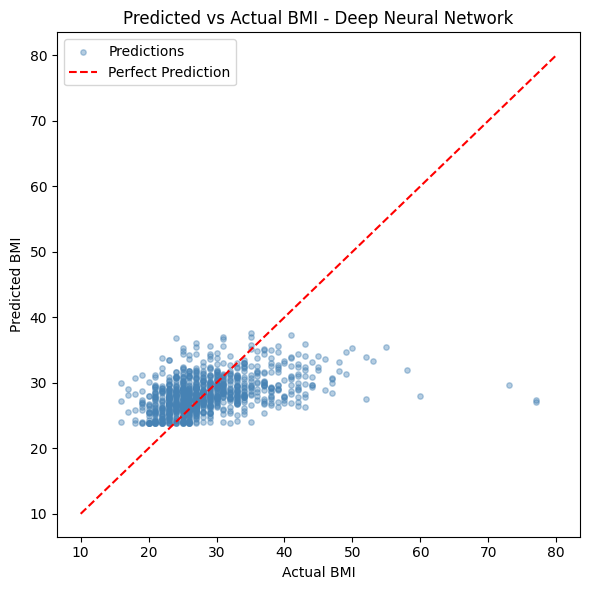

In [ ]:
# ============================================================
# Cell 14: Regression Results - Predicted vs Actual BMI
# A good model should cluster tightly around the diagonal line
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_reg_test[:1000], y_pred_deep_reg[:1000],
           alpha=0.4, color="steelblue", s=15, label="Predictions")
ax.plot([10, 80], [10, 80], "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_xlabel("Actual BMI")
ax.set_ylabel("Predicted BMI")
ax.set_title("Predicted vs Actual BMI - Deep Neural Network")
ax.legend()

plt.tight_layout()
plt.savefig("bmi_pred_vs_actual.png", dpi=150)
plt.show()

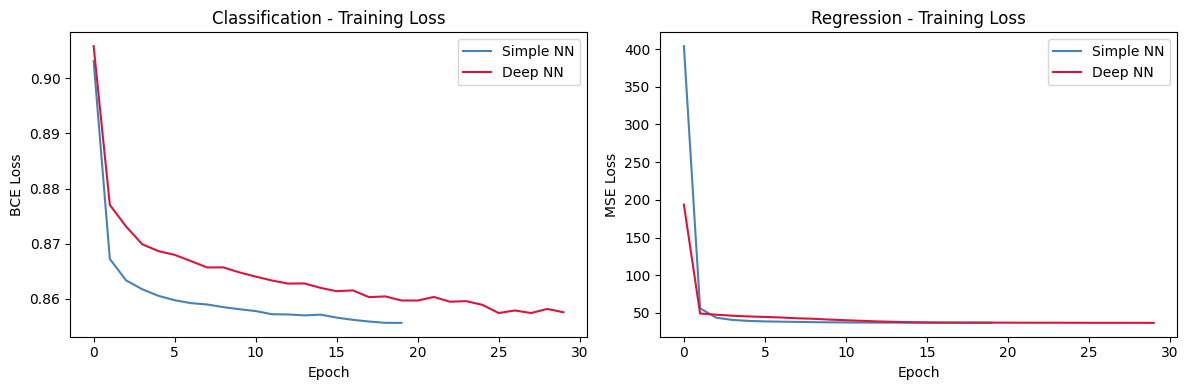

In [ ]:
# ============================================================
# Cell 15: Training Loss Curves
# Shows how each model improved during training over epochs
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(simple_clf_losses, label="Simple NN", color="steelblue")
axes[0].plot(deep_clf_losses,   label="Deep NN",   color="crimson")
axes[0].set_title("Classification - Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(simple_reg_losses, label="Simple NN", color="steelblue")
axes[1].plot(deep_reg_losses,   label="Deep NN",   color="crimson")
axes[1].set_title("Regression - Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_loss_curves.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# Experiment 5: Log Transform BMI Target
# ============================================================

y_reg_log = np.log(y_reg)

X_reg_train_e, X_reg_test_e, y_reg_train_log, y_reg_test_log = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

scaler_exp = StandardScaler()
X_reg_train_e_s = scaler_exp.fit_transform(X_reg_train_e)
X_reg_test_e_s  = scaler_exp.transform(X_reg_test_e)

reg_input_dim_e = X_reg_train_e_s.shape[1]
deep_reg_log    = DeepRegressorNN(reg_input_dim_e)
deep_reg_log, _ = train_regressor(deep_reg_log, X_reg_train_e_s, y_reg_train_log, epochs=50)

deep_reg_log.eval()
with torch.no_grad():
    y_pred_log = deep_reg_log(torch.FloatTensor(X_reg_test_e_s)).numpy()

y_pred_exp  = np.exp(y_pred_log)
y_test_exp  = np.exp(y_reg_test_log)

print("\n=== Deep NN Regression - Log Transform Results ===")
print(f"MAE:  {mean_absolute_error(y_test_exp, y_pred_exp):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)):.4f}")
print(f"R2:   {r2_score(y_test_exp, y_pred_exp):.4f}")

Epoch 01/50 - Loss: 0.7364
Epoch 02/50 - Loss: 0.1784
Epoch 03/50 - Loss: 0.0776
Epoch 04/50 - Loss: 0.0420
Epoch 05/50 - Loss: 0.0394
Epoch 06/50 - Loss: 0.0389
Epoch 07/50 - Loss: 0.0384
Epoch 08/50 - Loss: 0.0383
Epoch 09/50 - Loss: 0.0379
Epoch 10/50 - Loss: 0.0378
Epoch 11/50 - Loss: 0.0378
Epoch 12/50 - Loss: 0.0377
Epoch 13/50 - Loss: 0.0376
Epoch 14/50 - Loss: 0.0375
Epoch 15/50 - Loss: 0.0374
Epoch 16/50 - Loss: 0.0373
Epoch 17/50 - Loss: 0.0372
Epoch 18/50 - Loss: 0.0372
Epoch 19/50 - Loss: 0.0372
Epoch 20/50 - Loss: 0.0370
Epoch 21/50 - Loss: 0.0370
Epoch 22/50 - Loss: 0.0369
Epoch 23/50 - Loss: 0.0368
Epoch 24/50 - Loss: 0.0368
Epoch 25/50 - Loss: 0.0367
Epoch 26/50 - Loss: 0.0366
Epoch 27/50 - Loss: 0.0367
Epoch 28/50 - Loss: 0.0365
Epoch 29/50 - Loss: 0.0365
Epoch 30/50 - Loss: 0.0365
Epoch 31/50 - Loss: 0.0364
Epoch 32/50 - Loss: 0.0363
Epoch 33/50 - Loss: 0.0364
Epoch 34/50 - Loss: 0.0363
Epoch 35/50 - Loss: 0.0364
Epoch 36/50 - Loss: 0.0363
Epoch 37/50 - Loss: 0.0363
E

In [ ]:
# ============================================================
# Experiment 6: Feature Engineering
# Adding interaction terms to give the model richer signals
# ============================================================

df_reg = df.drop(columns=["Diabetes_binary"]).copy()

# Interaction terms
df_reg["Age_x_PhysActivity"] = df_reg["Age"] * df_reg["PhysActivity"]
df_reg["Age_x_GenHlth"]      = df_reg["Age"] * df_reg["GenHlth"]
df_reg["Smoker_x_PhysHlth"]  = df_reg["Smoker"] * df_reg["PhysHlth"]
df_reg["Income_x_Education"] = df_reg["Income"] * df_reg["Education"]

X_reg_fe = df_reg.drop(columns=["BMI"])
y_reg_fe  = df_reg["BMI"]

X_reg_train_fe, X_reg_test_fe, y_reg_train_fe, y_reg_test_fe = train_test_split(
    X_reg_fe, y_reg_fe, test_size=0.2, random_state=42
)

scaler_fe = StandardScaler()
X_reg_train_fe_s = scaler_fe.fit_transform(X_reg_train_fe)
X_reg_test_fe_s  = scaler_fe.transform(X_reg_test_fe)

reg_input_dim_fe = X_reg_train_fe_s.shape[1]
deep_reg_fe      = DeepRegressorNN(reg_input_dim_fe)
deep_reg_fe, _   = train_regressor(deep_reg_fe, X_reg_train_fe_s, y_reg_train_fe, epochs=50)

deep_reg_fe.eval()
with torch.no_grad():
    y_pred_fe = deep_reg_fe(torch.FloatTensor(X_reg_test_fe_s)).numpy()

print("\n=== Deep NN Regression - Feature Engineering Results ===")
print(f"MAE:  {mean_absolute_error(y_reg_test_fe, y_pred_fe):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test_fe, y_pred_fe)):.4f}")
print(f"R2:   {r2_score(y_reg_test_fe, y_pred_fe):.4f}")

Epoch 01/50 - Loss: 205.5894
Epoch 02/50 - Loss: 49.5004
Epoch 03/50 - Loss: 47.8249
Epoch 04/50 - Loss: 46.6095
Epoch 05/50 - Loss: 45.4418
Epoch 06/50 - Loss: 44.0739
Epoch 07/50 - Loss: 42.4272
Epoch 08/50 - Loss: 41.0286
Epoch 09/50 - Loss: 39.6858
Epoch 10/50 - Loss: 38.7673
Epoch 11/50 - Loss: 38.0648
Epoch 12/50 - Loss: 37.5730
Epoch 13/50 - Loss: 37.3543
Epoch 14/50 - Loss: 37.2298
Epoch 15/50 - Loss: 37.1260
Epoch 16/50 - Loss: 37.1662
Epoch 17/50 - Loss: 37.0805
Epoch 18/50 - Loss: 37.0750
Epoch 19/50 - Loss: 37.0021
Epoch 20/50 - Loss: 36.9619
Epoch 21/50 - Loss: 36.9111
Epoch 22/50 - Loss: 36.8642
Epoch 23/50 - Loss: 36.8983
Epoch 24/50 - Loss: 36.8465
Epoch 25/50 - Loss: 36.8145
Epoch 26/50 - Loss: 36.8330
Epoch 27/50 - Loss: 36.7282
Epoch 28/50 - Loss: 36.7507
Epoch 29/50 - Loss: 36.7317
Epoch 30/50 - Loss: 36.6799
Epoch 31/50 - Loss: 36.6883
Epoch 32/50 - Loss: 36.7146
Epoch 33/50 - Loss: 36.6781
Epoch 34/50 - Loss: 36.6303
Epoch 35/50 - Loss: 36.5937
Epoch 36/50 - Loss:

In [ ]:
# Best Classification Model — Deep NN threshold +0.5
torch.save(deep_clf_nn.state_dict(), "deep_clf_nn.pt")

# Best Regression Model — Original Deep NN
torch.save(deep_reg_nn.state_dict(), "deep_reg_nn.pt")

print("Models saved.")

Models saved.


In [ ]:
from google.colab import files
files.download("deep_clf_nn.pt")
files.download("deep_reg_nn.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(f"deep_clf_nn.pt: {os.path.getsize('deep_clf_nn.pt') / 1024:.2f} KB")
print(f"deep_reg_nn.pt: {os.path.getsize('deep_reg_nn.pt') / 1024:.2f} KB")

deep_clf_nn.pt: 55.19 KB
deep_reg_nn.pt: 60.39 KB
